In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

2025-09-12 14:18:33.950817: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-12 14:18:34.120441: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-12 14:18:34.279843: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757666914.405432 1111504 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757666914.438935 1111504 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1757666914.732028 1111504 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
# Load and preprocess MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
# Normalize pixel values to [0, 1] and flatten images to 1D vectors (28x28 = 784)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

In [4]:
print(x_train.shape, x_test.shape)
print(x_train_flat.shape, x_test_flat.shape)

(60000, 28, 28) (10000, 28, 28)
(60000, 784) (10000, 784)


In [5]:
# Define autoencoder parameters
input_dim = 784  # Flattened MNIST image size (28x28)
hidden_dim = 128  # Size of hidden layer
embedding_dim = 2  # Size of embedding (2D for visualization)
epochs = 50  # Number of training epochs
batch_size = 128  # Batch size for training

In [6]:
# Build the encoder
input_layer = Input(shape=(input_dim,))  # Input layer for flattened images
hidden_layer = Dense(hidden_dim, activation='relu')(input_layer)  # Hidden layer
embedding_layer = Dense(embedding_dim, activation='linear')(hidden_layer)  # Embedding layer (2D)
encoder = Model(input_layer, embedding_layer, name='encoder')  # Encoder model

2025-09-12 14:18:41.862460: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
# Build the decoder
hidden_decoder = Dense(hidden_dim, activation='relu')(embedding_layer)  # Hidden layer in decoder
output_layer = Dense(input_dim, activation='sigmoid')(hidden_decoder)  # Output layer to reconstruct image
autoencoder = Model(input_layer, output_layer, name='autoencoder')  # Full autoencoder model

In [8]:
# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [9]:
# Train the autoencoder
autoencoder.fit(
    x_train_flat, x_train_flat,  # Input and target are the same (reconstruction)
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_test_flat, x_test_flat),
    verbose=1
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2564 - val_loss: 0.2233
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2157 - val_loss: 0.2086
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2062 - val_loss: 0.2032
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2017 - val_loss: 0.2001
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1988 - val_loss: 0.1976
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1968 - val_loss: 0.1962
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1953 - val_loss: 0.1950
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1940 - val_loss: 0.1938
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1930 - val_loss: 0.1929
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1921 - val_loss: 0.1919
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1912 - val_loss: 0.1913
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

In [10]:
# Use the encoder to get embeddings for test data
embeddings = encoder.predict(x_test_flat, batch_size=batch_size, verbose=0)

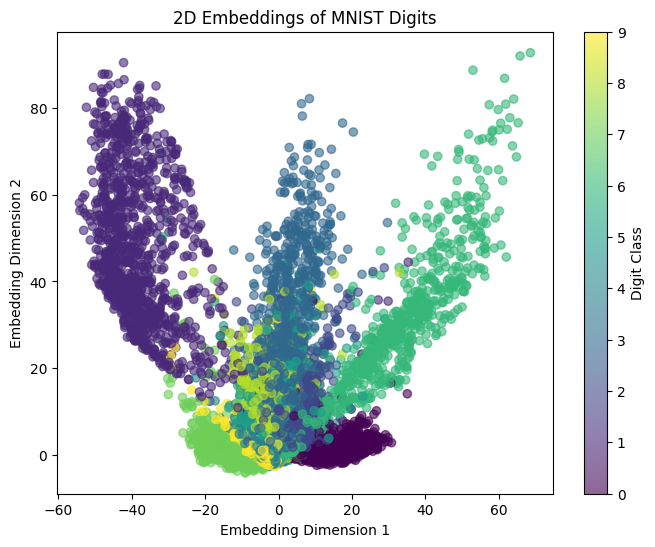

In [11]:
# Visualize the 2D embeddings
plt.figure(figsize=(8, 6))
plt.scatter(embeddings[:, 0], embeddings[:, 1], c=y_test, alpha=0.6, cmap='viridis')
plt.title('2D Embeddings of MNIST Digits')
plt.colorbar(label='Digit Class')
plt.xlabel('Embedding Dimension 1')
plt.ylabel('Embedding Dimension 2')
plt.show()

In [12]:
# Example: Print embeddings for specific digits
print("Embedding for test image 0 (digit", y_test[0], "):", embeddings[0])
print("Embedding for test image 1 (digit", y_test[1], "):", embeddings[1])

Embedding for test image 0 (digit 7 ): [-15.162929   1.383279]
Embedding for test image 1 (digit 2 ): [11.712757 23.911463]


In [13]:
# Let now take few of them and show you how vectors embeddings of similar digits are more closer to each other.
# Lets get few of those pictures and compare each of their embeddings.
# Lets take two 0s and two 1s

indices = np.where(y_test == 0)[0][:2]  # Get first two indices of digit '0'
embeddings_0 = embeddings[indices]

indices_1 = np.where(y_test == 1)[0][:2]  # Get first two indices of digit '1'
embeddings_1 = embeddings[indices_1]

# Print embeddings for the selected digits
print("Embeddings for two 0s:", embeddings_0)
print("Embeddings for two 1s:", embeddings_1)

Embeddings for two 0s: [[ 9.656623    1.4699396 ]
 [10.885724    0.34402657]]
Embeddings for two 1s: [[-45.450535  57.70364 ]
 [-47.71246   63.809746]]


In [ ]:
# Calculate Distance Metrics

# Euclidean Distance

In [18]:
embeddings_0_A = np.array(embeddings_0[0])
embeddings_0_B = np.array(embeddings_0[1])
L2 = [(embeddings_0_A[i] - embeddings_0_B[i])**2 for i in range(len(embeddings_0_A))]
L2_norm = np.sqrt(sum(L2))
print(f"L2 Norm between two 0s: {L2_norm}")

L2 Norm between two 0s: 1.6668442487716675


In [ ]:
# Alternative way to calculate L2 norm
L2_norm_alternative = np.linalg.norm((embeddings_0_A - embeddings_0_B), ord=2)
print(f"L2 Norm between two 0s: {L2_norm_alternative}")


L2 Norm between two 0s (alternative calculation): 1.6668442487716675


In [21]:
embeddings_1_A = np.array(embeddings_1[0])
embeddings_1_B = np.array(embeddings_1[1])

print("Distance between Zero_A and Zero_B:", np.linalg.norm((embeddings_0_A - embeddings_0_B), ord=2))
print("Distance between One_A and One_B:", np.linalg.norm((embeddings_1_A - embeddings_1_B), ord=2))
print("Distance between Zero_A and One_A:", np.linalg.norm((embeddings_0_A - embeddings_1_A), ord=2))

Distance between Zero_A and Zero_B: 1.6668442
Distance between One_A and One_B: 6.511592
Distance between Zero_A and One_A: 78.7339


In [22]:
# Manhattan Distance
L1_norm = [embeddings_0_A[i] - embeddings_0_B[i] for i in range(len(embeddings_0_A))]
L1_norm = np.abs(L1_norm).sum()
print(f"L1 Norm between two 0s: {L1_norm}")

L1 Norm between two 0s: 2.3550143241882324


In [23]:
# an alternative way to calculate L1 norm
L1_norm_alternative = np.linalg.norm((embeddings_0_A - embeddings_0_B), ord=1)
print(f"L1 Norm between two 0s: {L1_norm_alternative}")

L1 Norm between two 0s: 2.3550143241882324


In [24]:
# Calculate L1 distances
print("L1 Distance between Zero_A and Zero_B:", np.linalg.norm((embeddings_0_A - embeddings_0_B), ord=1))
print("L1 Distance between One_A and One_B:", np.linalg.norm((embeddings_1_A - embeddings_1_B), ord=1))
print("L1 Distance between Zero_A and One_A:", np.linalg.norm((embeddings_0_A - embeddings_1_A), ord=1))

L1 Distance between Zero_A and Zero_B: 2.3550143
L1 Distance between One_A and One_B: 8.368031
L1 Distance between Zero_A and One_A: 111.34086


In [25]:
# Dot Product
dot_product_0 = np.dot(embeddings_0_A, embeddings_0_B)
dot_product_1 = np.dot(embeddings_1_A, embeddings_1_B)
dot_product_01 = np.dot(embeddings_0_A, embeddings_1_A)

print("Dot Product between two 0s:", dot_product_0)
print("Dot Product between two 1s:", dot_product_1)
print("Dot Product between 0 and 1:", dot_product_01)

Dot Product between two 0s: 105.62503
Dot Product between two 1s: 5850.6113
Dot Product between 0 and 1: -354.07782


In [30]:
# Cosine Distance
cosine_similarity_0 = np.dot(embeddings_0_A, embeddings_0_B) / (np.linalg.norm(embeddings_0_A) * np.linalg.norm(embeddings_0_B))
cosine_distance_0 = 1 - cosine_similarity_0
print(f"Cosine Distance between two 0s: {cosine_distance_0}")

Cosine Distance between two 0s: 0.0071277618408203125


In [ ]:
# alternative way to calculate cosine distance
cosine_similarity_0 = dot_product_0 / (np.linalg.norm(embeddings_0_A) * np.linalg.norm(embeddings_0_B))
cosine_distance_0 = 1 - cosine_similarity_0
print(f"Cosine Distance between two 0s: {cosine_distance_0}")

Cosine Distance between two 0s: 0.0071277618408203125


In [32]:
# Calculate Cosine Distance
cosine_similarity_0 = dot_product_0 / (np.linalg.norm(embeddings_0_A) * np.linalg.norm(embeddings_0_B))
cosine_distance_0 = 1 - cosine_similarity_0
cosine_similarity_1 = 1 - dot_product_1 / (np.linalg.norm(embeddings_1_A) * np.linalg.norm(embeddings_1_B))
cosine_distance_1 = 1 - cosine_similarity_1
cosine_similarity_01 = 1 - dot_product_01 / (np.linalg.norm(embeddings_0_A) * np.linalg.norm(embeddings_1_A))
cosine_distance_01 = 1 - cosine_similarity_01

print("Cosine Distance between two 0s:", cosine_distance_0)
print("Cosine Distance between two 1s:", cosine_distance_1)
print("Cosine Distance between 0 and 1:", cosine_distance_01)

Cosine Distance between two 0s: 0.007127762
Cosine Distance between two 1s: 0.99968445
Cosine Distance between 0 and 1: -0.4934976


### Using Advanced Models

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

In [ ]:
sentences = ['A dog barked loudly in the yard.',
            'A canine made noise outside.',
            'The stock market crashed yesterday.']

In [ ]:
embeddings = model.encode(sentences)
print("Embeddings for sentences:")
for i, sentence in enumerate(sentences):
    print(f"Sentence: {sentence}\nEmbedding: {embeddings[i][:10]}\n")
    print(f"Embedding shape: {embeddings[i].shape}\n")

In [ ]:
# Visualizing embeddings for sentences
plt.figure(figsize=(8, 6))
plt.scatter(embeddings[:, 0], embeddings[:, 1], alpha=0.6, cmap='viridis')
for i, sentence in enumerate(sentences):
    plt.annotate(sentence, (embeddings[i, 0], embeddings[i, 1]), fontsize=9)
plt.title('2D Embeddings of Sentences')
plt.xlabel('Embedding Dimension 1')
plt.ylabel('Embedding Dimension 2')
plt.show()